In [111]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

torch.set_default_dtype(torch.float64)

k_true = 0.05
x_env = 20.0
initial_temp = 90.0
sigma_obs = 4.0
n = 20
T = 60.0

def newton_cooling(k, x_env, x0, t):
    return x_env + (x0 - x_env) * np.exp(-k * t)

rng = np.random.RandomState(0)
t_obs_np = np.linspace(0, T, n)
x_true_np = newton_cooling(k_true, x_env, initial_temp, t_obs_np)
y_obs_np = x_true_np + rng.normal(0, sigma_obs, size=n)

t_obs = torch.tensor(t_obs_np)
y_obs = torch.tensor(y_obs_np)

print(f"n={n}, t range=[{t_obs_np[0]:.1f}, {t_obs_np[-1]:.1f}]")

n=20, t range=[0.0, 60.0]


In [112]:
def rbf_kernel(t1, t2, sigma_f2, l):
    sqdist = (t1.unsqueeze(1) - t2.unsqueeze(0))**2
    return sigma_f2 * torch.exp(-0.5 * sqdist / l**2)

In [113]:
def k_d1(u, sigma_f2, l):
    return -(u/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def k_d2(u, sigma_f2, l):
    return (u**2/l**4 - 1/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def rbf_kernel_from_u(u, sigma_f2, l):
    return sigma_f2 * torch.exp(-0.5 * u**2 / l**2)

def pairwise_diff(t1, t2):
    return t1.unsqueeze(1) - t2.unsqueeze(0)

def build_covariance_blocks(t, sigma_f2, l):
    u = pairwise_diff(t, t)

    C_xx = rbf_kernel_from_u(u, sigma_f2, l)
    C_xdotx = k_d1(u, sigma_f2, l)      # cov(xdot, x')
    C_xxdot = -k_d1(u, sigma_f2, l)     # cov(x, xdot')
    C_xdotxdot = -k_d2(u, sigma_f2, l)  # cov(xdot, xdot')

    return {'xx': C_xx, 'xxdot': C_xxdot, 'xdotx': C_xdotx, 'xdotxdot': C_xdotxdot}

In [114]:
sf2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

C_test = build_covariance_blocks(t_obs, sf2_test, l_test)
for key, mat in C_test.items():
    print(f"{key}: shape={mat.shape}, symmetric={'yes' if key in ('xx','xdotxdot') else 'n/a (cross-term)'}")

print("C_xx diagonal (should be all sigma_f2=1.0):", torch.diagonal(C_test['xx'])[:5])

xx: shape=torch.Size([20, 20]), symmetric=yes
xxdot: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotx: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotxdot: shape=torch.Size([20, 20]), symmetric=yes
C_xx diagonal (should be all sigma_f2=1.0): tensor([1., 1., 1., 1., 1.])


In [115]:
def log_likelihood_y_given_xdot(xdot, k_param, mu_x, sigma2_obs, C, rel_jitter=1e-6):
    n = len(xdot)
    I = torch.eye(n)

    jitter = rel_jitter * torch.diagonal(C['xdotxdot']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)  # guard against a degenerate all-zero diagonal

    L_xdotxdot = torch.linalg.cholesky(C['xdotxdot'] + jitter * I)
    xdot_centered = xdot.unsqueeze(1)
    solved = torch.cholesky_solve(xdot_centered, L_xdotxdot).squeeze(1)

    mean_x_given_xdot = mu_x + C['xxdot'] @ solved
    Sigma_x_given_xdot = C['xx'] - C['xxdot'] @ torch.cholesky_solve(C['xdotx'], L_xdotxdot)

    mean_y = mean_x_given_xdot
    cov_y = Sigma_x_given_xdot + sigma2_obs * I
    cov_y = (cov_y + cov_y.T) / 2 + jitter * I

    dist = torch.distributions.MultivariateNormal(mean_y, covariance_matrix=cov_y)
    return dist

In [116]:
mu_x_test = y_obs.mean()
xdot_placeholder = torch.zeros(n)  # arbitrary test input, not yet ODE-derived

dist_test = log_likelihood_y_given_xdot(xdot_placeholder, k_true, mu_x_test, sigma_obs**2, C_test)
print("mean_y range:", dist_test.mean.min().item(), dist_test.mean.max().item())
print("cov_y diagonal range:", torch.diagonal(dist_test.covariance_matrix).min().item(),
      torch.diagonal(dist_test.covariance_matrix).max().item())

mean_y range: 45.22126069337545 45.22126069337545
cov_y diagonal range: 16.248066686032043 16.248104656128653


In [117]:
def log_posterior_k_phi_x(k_param, x, sigma_f2, l, sigma2_obs, mu_x, y_obs, t_obs):
    C = build_covariance_blocks(t_obs, sigma_f2, l)
    xdot_ode = -k_param * (x - x_env)
    dist = log_likelihood_y_given_xdot(xdot_ode, k_param, mu_x, sigma2_obs, C)
    log_lik = dist.log_prob(y_obs)
    return log_lik


In [118]:
mu_x_test = y_obs.mean()
sigma_f2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

ll_true = log_posterior_k_phi_x(k_true, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong1 = log_posterior_k_phi_x(0.02, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong2 = log_posterior_k_phi_x(0.15, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)

print(f"log-lik at true k=0.05:  {ll_true.item():.2f}")
print(f"log-lik at wrong k=0.02: {ll_wrong1.item():.2f}")
print(f"log-lik at wrong k=0.15: {ll_wrong2.item():.2f}")

log-lik at true k=0.05:  -632.25
log-lik at wrong k=0.02: -239.33
log-lik at wrong k=0.15: -6446.38


In [119]:
k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)

theta_prior_dist_literal = torch.distributions.Gamma(concentration=4.0, rate=0.5)
log_probs_literal = theta_prior_dist_literal.log_prob(k_grid)
print("Literal paper Gamma(4,0.5) log-probs across k_grid:")
print(f"  min={log_probs_literal.min().item():.2f}, max={log_probs_literal.max().item():.2f}")

Literal paper Gamma(4,0.5) log-probs across k_grid:
  min=-18.38, max=-10.33


In [120]:
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
log_probs_rescaled = theta_prior_dist.log_prob(k_grid)
print("Rescaled Gamma(1.5, 20) log-probs across k_grid:")
print(f"  min={log_probs_rescaled.min().item():.2f}, max={log_probs_rescaled.max().item():.2f}")
print(f"  mode = {(1.5-1)/20:.4f}  (target: near k_true={k_true})")

Rescaled Gamma(1.5, 20) log-probs across k_grid:
  min=0.67, max=2.27
  mode = 0.0250  (target: near k_true=0.05)


In [121]:
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
def log_prior_theta(k):
    return theta_prior_dist.log_prob(torch.tensor(k)).item()

sigma_prior_dist = torch.distributions.Gamma(concentration=1.0, rate=1.0)
def log_prior_phi(sigma_f2, l, sigma2):
    log_p_sf2 = 0.0 if 0 < sigma_f2 < 100 else -float('inf')
    log_p_l   = 0.0 if 0 < l < 100 else -float('inf')
    sigma = np.sqrt(sigma2)
    log_p_sigma = sigma_prior_dist.log_prob(torch.tensor(sigma)).item()
    return log_p_sf2 + log_p_l + log_p_sigma

k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

torch.set_default_dtype(torch.float64)

k_true = 0.05
x_env = 20.0
initial_temp = 90.0
sigma_obs = 4.0
n = 20
T = 60.0

def newton_cooling(k, x_env, x0, t):
    return x_env + (x0 - x_env) * np.exp(-k * t)

rng = np.random.RandomState(0)
t_obs_np = np.linspace(0, T, n)
x_true_np = newton_cooling(k_true, x_env, initial_temp, t_obs_np)
y_obs_np = x_true_np + rng.normal(0, sigma_obs, size=n)

t_obs = torch.tensor(t_obs_np)
y_obs = torch.tensor(y_obs_np)

print(f"n={n}, t range=[{t_obs_np[0]:.1f}, {t_obs_np[-1]:.1f}]")
def rbf_kernel(t1, t2, sigma_f2, l):
    sqdist = (t1.unsqueeze(1) - t2.unsqueeze(0))**2
    return sigma_f2 * torch.exp(-0.5 * sqdist / l**2)
def k_d1(u, sigma_f2, l):
    return -(u/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def k_d2(u, sigma_f2, l):
    return (u**2/l**4 - 1/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def rbf_kernel_from_u(u, sigma_f2, l):
    return sigma_f2 * torch.exp(-0.5 * u**2 / l**2)

def pairwise_diff(t1, t2):
    return t1.unsqueeze(1) - t2.unsqueeze(0)

def build_covariance_blocks(t, sigma_f2, l):
    u = pairwise_diff(t, t)

    C_xx = rbf_kernel_from_u(u, sigma_f2, l)
    C_xdotx = k_d1(u, sigma_f2, l)      # cov(xdot, x')
    C_xxdot = -k_d1(u, sigma_f2, l)     # cov(x, xdot')
    C_xdotxdot = -k_d2(u, sigma_f2, l)  # cov(xdot, xdot')

    return {'xx': C_xx, 'xxdot': C_xxdot, 'xdotx': C_xdotx, 'xdotxdot': C_xdotxdot}
sf2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

C_test = build_covariance_blocks(t_obs, sf2_test, l_test)
for key, mat in C_test.items():
    print(f"{key}: shape={mat.shape}, symmetric={'yes' if key in ('xx','xdotxdot') else 'n/a (cross-term)'}")

print("C_xx diagonal (should be all sigma_f2=1.0):", torch.diagonal(C_test['xx'])[:5])
def log_likelihood_y_given_xdot(xdot, k_param, mu_x, sigma2_obs, C, rel_jitter=1e-6):
    n = len(xdot)
    I = torch.eye(n)

    jitter = rel_jitter * torch.diagonal(C['xdotxdot']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)  # guard against a degenerate all-zero diagonal

    L_xdotxdot = torch.linalg.cholesky(C['xdotxdot'] + jitter * I)
    xdot_centered = xdot.unsqueeze(1)
    solved = torch.cholesky_solve(xdot_centered, L_xdotxdot).squeeze(1)

    mean_x_given_xdot = mu_x + C['xxdot'] @ solved
    Sigma_x_given_xdot = C['xx'] - C['xxdot'] @ torch.cholesky_solve(C['xdotx'], L_xdotxdot)

    mean_y = mean_x_given_xdot
    cov_y = Sigma_x_given_xdot + sigma2_obs * I
    cov_y = (cov_y + cov_y.T) / 2 + jitter * I

    dist = torch.distributions.MultivariateNormal(mean_y, covariance_matrix=cov_y)
    return dist
mu_x_test = y_obs.mean()
xdot_placeholder = torch.zeros(n)  # arbitrary test input, not yet ODE-derived

dist_test = log_likelihood_y_given_xdot(xdot_placeholder, k_true, mu_x_test, sigma_obs**2, C_test)
print("mean_y range:", dist_test.mean.min().item(), dist_test.mean.max().item())
print("cov_y diagonal range:", torch.diagonal(dist_test.covariance_matrix).min().item(),
      torch.diagonal(dist_test.covariance_matrix).max().item())
def log_posterior_k_phi_x(k_param, x, sigma_f2, l, sigma2_obs, mu_x, y_obs, t_obs):
    C = build_covariance_blocks(t_obs, sigma_f2, l)
    xdot_ode = -k_param * (x - x_env)
    dist = log_likelihood_y_given_xdot(xdot_ode, k_param, mu_x, sigma2_obs, C)
    log_lik = dist.log_prob(y_obs)
    return log_lik

mu_x_test = y_obs.mean()
sigma_f2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

ll_true = log_posterior_k_phi_x(k_true, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong1 = log_posterior_k_phi_x(0.02, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong2 = log_posterior_k_phi_x(0.15, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)

print(f"log-lik at true k=0.05:  {ll_true.item():.2f}")
print(f"log-lik at wrong k=0.02: {ll_wrong1.item():.2f}")
print(f"log-lik at wrong k=0.15: {ll_wrong2.item():.2f}")
k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)

theta_prior_dist_literal = torch.distributions.Gamma(concentration=4.0, rate=0.5)
log_probs_literal = theta_prior_dist_literal.log_prob(k_grid)
print("Literal paper Gamma(4,0.5) log-probs across k_grid:")
print(f"  min={log_probs_literal.min().item():.2f}, max={log_probs_literal.max().item():.2f}")
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
log_probs_rescaled = theta_prior_dist.log_prob(k_grid)
print("Rescaled Gamma(1.5, 20) log-probs across k_grid:")
print(f"  min={log_probs_rescaled.min().item():.2f}, max={log_probs_rescaled.max().item():.2f}")
print(f"  mode = {(1.5-1)/20:.4f}  (target: near k_true={k_true})")
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
def log_prior_theta(k):
    return theta_prior_dist.log_prob(torch.tensor(k)).item()

sigma_prior_dist = torch.distributions.Gamma(concentration=1.0, rate=1.0)
def log_prior_phi(sigma_f2, l, sigma2):
    log_p_sf2 = 0.0 if 0 < sigma_f2 < 100 else -float('inf')
    log_p_l   = 0.0 if 0 < l < 100 else -float('inf')
    sigma = np.sqrt(sigma2)
    log_p_sigma = sigma_prior_dist.log_prob(torch.tensor(sigma)).item()
    return log_p_sf2 + log_p_l + log_p_sigma

k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

torch.set_default_dtype(torch.float64)

k_true = 0.05
x_env = 20.0
initial_temp = 90.0
sigma_obs = 4.0
n = 20
T = 60.0

def newton_cooling(k, x_env, x0, t):
    return x_env + (x0 - x_env) * np.exp(-k * t)

rng = np.random.RandomState(0)
t_obs_np = np.linspace(0, T, n)
x_true_np = newton_cooling(k_true, x_env, initial_temp, t_obs_np)
y_obs_np = x_true_np + rng.normal(0, sigma_obs, size=n)

t_obs = torch.tensor(t_obs_np)
y_obs = torch.tensor(y_obs_np)

print(f"n={n}, t range=[{t_obs_np[0]:.1f}, {t_obs_np[-1]:.1f}]")
def rbf_kernel(t1, t2, sigma_f2, l):
    sqdist = (t1.unsqueeze(1) - t2.unsqueeze(0))**2
    return sigma_f2 * torch.exp(-0.5 * sqdist / l**2)
def k_d1(u, sigma_f2, l):
    return -(u/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def k_d2(u, sigma_f2, l):
    return (u**2/l**4 - 1/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def rbf_kernel_from_u(u, sigma_f2, l):
    return sigma_f2 * torch.exp(-0.5 * u**2 / l**2)

def pairwise_diff(t1, t2):
    return t1.unsqueeze(1) - t2.unsqueeze(0)

def build_covariance_blocks(t, sigma_f2, l):
    u = pairwise_diff(t, t)

    C_xx = rbf_kernel_from_u(u, sigma_f2, l)
    C_xdotx = k_d1(u, sigma_f2, l)      # cov(xdot, x')
    C_xxdot = -k_d1(u, sigma_f2, l)     # cov(x, xdot')
    C_xdotxdot = -k_d2(u, sigma_f2, l)  # cov(xdot, xdot')

    return {'xx': C_xx, 'xxdot': C_xxdot, 'xdotx': C_xdotx, 'xdotxdot': C_xdotxdot}
sf2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

C_test = build_covariance_blocks(t_obs, sf2_test, l_test)
for key, mat in C_test.items():
    print(f"{key}: shape={mat.shape}, symmetric={'yes' if key in ('xx','xdotxdot') else 'n/a (cross-term)'}")

print("C_xx diagonal (should be all sigma_f2=1.0):", torch.diagonal(C_test['xx'])[:5])
def log_likelihood_y_given_xdot(xdot, k_param, mu_x, sigma2_obs, C, rel_jitter=1e-6):
    n = len(xdot)
    I = torch.eye(n)

    jitter = rel_jitter * torch.diagonal(C['xdotxdot']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)  # guard against a degenerate all-zero diagonal

    L_xdotxdot = torch.linalg.cholesky(C['xdotxdot'] + jitter * I)
    xdot_centered = xdot.unsqueeze(1)
    solved = torch.cholesky_solve(xdot_centered, L_xdotxdot).squeeze(1)

    mean_x_given_xdot = mu_x + C['xxdot'] @ solved
    Sigma_x_given_xdot = C['xx'] - C['xxdot'] @ torch.cholesky_solve(C['xdotx'], L_xdotxdot)

    mean_y = mean_x_given_xdot
    cov_y = Sigma_x_given_xdot + sigma2_obs * I
    cov_y = (cov_y + cov_y.T) / 2 + jitter * I

    dist = torch.distributions.MultivariateNormal(mean_y, covariance_matrix=cov_y)
    return dist
mu_x_test = y_obs.mean()
xdot_placeholder = torch.zeros(n)  # arbitrary test input, not yet ODE-derived

dist_test = log_likelihood_y_given_xdot(xdot_placeholder, k_true, mu_x_test, sigma_obs**2, C_test)
print("mean_y range:", dist_test.mean.min().item(), dist_test.mean.max().item())
print("cov_y diagonal range:", torch.diagonal(dist_test.covariance_matrix).min().item(),
      torch.diagonal(dist_test.covariance_matrix).max().item())
def log_posterior_k_phi_x(k_param, x, sigma_f2, l, sigma2_obs, mu_x, y_obs, t_obs):
    C = build_covariance_blocks(t_obs, sigma_f2, l)
    xdot_ode = -k_param * (x - x_env)
    dist = log_likelihood_y_given_xdot(xdot_ode, k_param, mu_x, sigma2_obs, C)
    log_lik = dist.log_prob(y_obs)
    return log_lik

mu_x_test = y_obs.mean()
sigma_f2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

ll_true = log_posterior_k_phi_x(k_true, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong1 = log_posterior_k_phi_x(0.02, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong2 = log_posterior_k_phi_x(0.15, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)

print(f"log-lik at true k=0.05:  {ll_true.item():.2f}")
print(f"log-lik at wrong k=0.02: {ll_wrong1.item():.2f}")
print(f"log-lik at wrong k=0.15: {ll_wrong2.item():.2f}")
k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)

theta_prior_dist_literal = torch.distributions.Gamma(concentration=4.0, rate=0.5)
log_probs_literal = theta_prior_dist_literal.log_prob(k_grid)
print("Literal paper Gamma(4,0.5) log-probs across k_grid:")
print(f"  min={log_probs_literal.min().item():.2f}, max={log_probs_literal.max().item():.2f}")
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
log_probs_rescaled = theta_prior_dist.log_prob(k_grid)
print("Rescaled Gamma(1.5, 20) log-probs across k_grid:")
print(f"  min={log_probs_rescaled.min().item():.2f}, max={log_probs_rescaled.max().item():.2f}")
print(f"  mode = {(1.5-1)/20:.4f}  (target: near k_true={k_true})")
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
def log_prior_theta(k):
    return theta_prior_dist.log_prob(torch.tensor(k)).item()

sigma_prior_dist = torch.distributions.Gamma(concentration=1.0, rate=1.0)
def log_prior_phi(sigma_f2, l, sigma2):
    log_p_sf2 = 0.0 if 0 < sigma_f2 < 100 else -float('inf')
    log_p_l   = 0.0 if 0 < l < 100 else -float('inf')
    sigma = np.sqrt(sigma2)
    log_p_sigma = sigma_prior_dist.log_prob(torch.tensor(sigma)).item()
    return log_p_sf2 + log_p_l + log_p_sigma

k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)
sigma_f2_grid = torch.linspace(0.1, 99.9, 10)
l_grid = torch.linspace(1.0, 60.0, 10)
sigma2_grid = torch.arange(1.0, 30.0+1e-9, 1.0)

mu_x = y_obs.mean()

print(f"k_grid: {len(k_grid)} points, [{k_grid[0]:.3f}, {k_grid[-1]:.3f}]")
print(f"sigma_f2_grid: {len(sigma_f2_grid)} points, [{sigma_f2_grid[0]:.2f}, {sigma_f2_grid[-1]:.2f}]")
print(f"l_grid: {len(l_grid)} points, [{l_grid[0]:.2f}, {l_grid[-1]:.2f}]")
print(f"sigma2_grid: {len(sigma2_grid)} points, [{sigma2_grid[0]:.2f}, {sigma2_grid[-1]:.2f}]")
def log_gp_prior_x(x, sigma_f2, l, mu_x, rel_jitter=1e-6):
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    n = len(x)
    jitter = rel_jitter * sigma_f2
    Cxx_j = C['xx'] + jitter * torch.eye(n)
    dist = torch.distributions.MultivariateNormal(mu_x * torch.ones(n), covariance_matrix=Cxx_j)
    return dist.log_prob(x).item()


def log_posterior_full(k_param, sigma_f2, l, sigma2, x, y_obs, t_obs):
    log_lik = log_posterior_k_phi_x(k_param, x, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)
    log_prior_x = log_gp_prior_x(x, sigma_f2, l, mu_x)
    return log_lik.item() + log_prior_x + log_prior_theta(k_param) + log_prior_phi(sigma_f2, l, sigma2)
n_bins_x = 20
x_bandwidth = 3 * sigma_obs

def x_grid_at(idx):
    center = y_obs[idx]
    return torch.linspace(center - x_bandwidth, center + x_bandwidth, n_bins_x)

print(x_grid_at(0))
def sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (a): Phi ~ p(Phi | X, theta, Y) -- sigma_f2, l, sigma2 in turn, theta fixed."""
    log_probs = torch.tensor([
        log_posterior_full(k_param, sf.item(), l, sigma2, x_current, y_obs, t_obs)
        for sf in sigma_f2_grid
    ])
    sigma_f2 = sigma_f2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, lg.item(), sigma2, x_current, y_obs, t_obs)
        for lg in l_grid
    ])
    l = l_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, l, s2.item(), x_current, y_obs, t_obs)
        for s2 in sigma2_grid
    ])
    sigma2 = sigma2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    return sigma_f2, l, sigma2


def sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (b): theta ~ p(theta | X, Phi, Y) -- Phi fixed (just updated in step a)."""
    log_probs = torch.tensor([
        log_posterior_full(kk.item(), sigma_f2, l, sigma2, x_current, y_obs, t_obs)
        for kk in k_grid
    ])
    k_param = k_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()
    return k_param


def gibbs_sweep_k_phi(x_current, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=1):
    """Paper Section 3.1: for j=1:L_p, (a) Phi | theta, then (b) theta | Phi."""
    for _ in range(L_p):
        sigma_f2, l, sigma2 = sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
        k_param = sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
    return k_param, sigma_f2, l, sigma2
import time
x_test = y_obs.clone()

t0 = time.time()
k_new, sf2_new, l_new, s2_new = gibbs_sweep_k_phi(x_test, k_true, 1.0, 10.0, sigma_obs**2, t_obs, y_obs)
t1 = time.time()

print(f"one param sweep: {t1-t0:.3f}s")
print(f"k: {k_true} -> {k_new:.4f}")
print(f"sigma_f2: 1.0 -> {sf2_new:.4f}")
print(f"l: 10.0 -> {l_new:.4f}")
print(f"sigma2: {sigma_obs**2} -> {s2_new:.4f}")
def gp_prior_conditional_at_t(idx, x_current, mu_x, C, rel_jitter=1e-6):
    n = len(x_current)
    idx_others = [i for i in range(n) if i != idx]

    C_kk = C['xx'][idx, idx]
    C_k_others = C['xx'][idx, idx_others]
    C_others_others = C['xx'][idx_others][:, idx_others]

    jitter = rel_jitter * torch.diagonal(C['xx']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)

    L = torch.linalg.cholesky(C_others_others + jitter * torch.eye(n-1))
    x_others_centered = (x_current[idx_others] - mu_x).unsqueeze(1)
    solved = torch.cholesky_solve(x_others_centered, L).squeeze(1)

    mean_k = mu_x + C_k_others @ solved
    var_k = C_kk - C_k_others @ torch.cholesky_solve(C_k_others.unsqueeze(1), L).squeeze(1)
    var_k = torch.clamp(var_k, min=jitter)

    return mean_k, var_k


def sample_x_at_t(idx, x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    grid = x_grid_at(idx)
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))

    mean_k, var_k = gp_prior_conditional_at_t(idx, x_current, mu_x, C)
    prior_dist = torch.distributions.Normal(mean_k, torch.sqrt(var_k))

    log_probs = []
    for x_val in grid:
        x_proposal = x_current.clone()
        x_proposal[idx] = x_val

        log_prior = prior_dist.log_prob(x_val)
        log_lik = log_posterior_k_phi_x(k_param, x_proposal, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)

        log_probs.append((log_prior + log_lik).item())

    log_probs = torch.tensor(log_probs)
    probs = torch.softmax(log_probs, dim=0)
    return grid[torch.multinomial(probs, 1)].item()


def gibbs_sweep_x(x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    x_new = x_current.clone()
    for idx in range(len(x_current)):
        x_new[idx] = sample_x_at_t(idx, x_new, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)
    return x_new
t0 = time.time()
x_val_test = sample_x_at_t(0, y_obs.clone(), k_true, 1.0, 10.0, sigma_obs**2, mu_x, t_obs, y_obs)
t1 = time.time()
print(f"one time-point update: {t1-t0:.3f}s, sampled value: {x_val_test:.4f}")
# get one real, GP-smoothed x using the paper's own initialization step (X^0 ~ p_GP(X|Y,Phi^0))
sigma_f2_init, l_init, sigma2_init = 1.0, 10.0, sigma_obs**2
C_init = build_covariance_blocks(t_obs, torch.tensor(sigma_f2_init), torch.tensor(l_init))
L_init = torch.linalg.cholesky(C_init['xx'] + sigma2_init*torch.eye(n) + 1e-6*torch.eye(n))
alpha_init = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L_init).squeeze(1)
x_smoothed = mu_x + C_init['xx'] @ alpha_init

# now re-check log_gp_prior_x across l_grid using this smoothed x instead of raw y_obs
for l_val in l_grid:
    lp = log_gp_prior_x(x_smoothed, 88.9444, l_val.item(), mu_x)
    print(f"l={l_val.item():.2f}: log_gp_prior_x = {lp:.2f}")
def random_init_k_phi(seed=0):
    torch.manual_seed(seed)
    k0 = k_grid[torch.randint(len(k_grid), (1,))].item()
    sf2_0 = sigma_f2_grid[torch.randint(len(sigma_f2_grid), (1,))].item()
    l0 = l_grid[torch.randint(len(l_grid), (1,))].item()
    s2_0 = sigma2_grid[torch.randint(len(sigma2_grid), (1,))].item()
    return k0, sf2_0, l0, s2_0


def run_gibbs(L, L_p, L_x, t_obs, y_obs, mu_x, init_k, init_phi, seed=0):
    torch.manual_seed(seed)
    k_param = init_k
    sigma_f2, l, sigma2 = init_phi

    C0 = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    L0 = torch.linalg.cholesky(C0['xx'] + sigma2*torch.eye(len(t_obs)) + 1e-6*torch.eye(len(t_obs)))
    alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
    x = mu_x + C0['xx'] @ alpha0

    samples = {'k': [], 'sigma_f2': [], 'l': [], 'sigma2': [], 'x_snapshot': []}

    for i in range(L):
        t0 = time.time()

        k_param, sigma_f2, l, sigma2 = gibbs_sweep_k_phi(x, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=L_p)

        for _ in range(L_x):
            x = gibbs_sweep_x(x, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)

        samples['k'].append(k_param)
        samples['sigma_f2'].append(sigma_f2)
        samples['l'].append(l)
        samples['sigma2'].append(sigma2)
        samples['x_snapshot'].append(x.clone())

        print(f"iter {i+1}/{L}  k={k_param:.4f}  sigma_f2={sigma_f2:.2f}  l={l:.2f}  sigma2={sigma2:.2f}  ({time.time()-t0:.2f}s)")

    return samples
init_k, sf2_0, l0, s2_0 = random_init_k_phi(seed=0)
init_phi_vals = (sf2_0, l0, s2_0)
print(f"random init: k={init_k}, phi={init_phi_vals}")

samples_Lx10 = run_gibbs(
    L=200, L_p=1, L_x=5,
    t_obs=t_obs, y_obs=y_obs, mu_x=mu_x,
    init_k=init_k, init_phi=init_phi_vals,
    seed=0
)
plt.figure(figsize=(9,4))
plt.plot(samples_Lx10['k'])
plt.axhline(k_true, color='k', linestyle='--', label='true k')
plt.xlabel('iteration'); plt.ylabel('k'); plt.legend()
plt.title('k trace, full run')
plt.show()

# second half only, to separate burn-in from settled behavior
burn_in = 100
plt.figure(figsize=(9,4))
plt.plot(range(burn_in, len(samples_Lx10['k'])), samples_Lx10['k'][burn_in:])
plt.axhline(k_true, color='k', linestyle='--', label='true k')
plt.xlabel('iteration'); plt.ylabel('k'); plt.legend()
plt.title(f'k trace, iterations {burn_in}-{len(samples_Lx10["k"])}')
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(samples_Lx10['k'])
axes[0,0].axhline(k_true, color='k', linestyle='--', label='true k')
axes[0,0].set_title('k trace'); axes[0,0].set_xlabel('iteration'); axes[0,0].legend()

axes[0,1].plot(samples_Lx10['l'])
axes[0,1].axhline(l_grid[0].item(), color='r', linestyle=':', label='grid floor')
axes[0,1].set_title('l trace'); axes[0,1].set_xlabel('iteration'); axes[0,1].legend()

axes[1,0].plot(samples_Lx10['sigma_f2'])
axes[1,0].set_title('sigma_f2 trace'); axes[1,0].set_xlabel('iteration')

axes[1,1].plot(samples_Lx10['sigma2'])
axes[1,1].axhline(sigma_obs**2, color='k', linestyle='--', label='true sigma2_obs')
axes[1,1].set_title('sigma2 trace'); axes[1,1].set_xlabel('iteration'); axes[1,1].legend()

plt.tight_layout()
plt.show()
l_arr = np.array(samples_Lx10['l'])
floor = l_grid[0].item()
frac_at_floor = np.mean(np.isclose(l_arr, floor, atol=1e-9))
print(f"l grid floor = {floor}")
print(f"fraction of iterations with l at floor: {frac_at_floor:.1%}")
print(f"l value counts (first 10 unique): {np.unique(l_arr)[:10]}")
burn_in = 100
k_post = np.array(samples_Lx10['k'][burn_in:])

k_mean = k_post.mean()
k_std = k_post.std()
ci_lo, ci_hi = np.percentile(k_post, [2.5, 97.5])

print(f"k posterior mean: {k_mean:.4f}")
print(f"k posterior std:  {k_std:.4f}")
print(f"95% CI (empirical percentile): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"true k = {k_true}, inside CI: {ci_lo <= k_true <= ci_hi}")

plt.figure(figsize=(7,4))
plt.hist(k_post, bins=20, color='tab:blue', alpha=0.7)
plt.axvline(k_true, color='k', linestyle='--', label='true k')
plt.axvline(k_mean, color='tab:red', linestyle='-', label='posterior mean')
plt.xlabel('k'); plt.ylabel('count')
plt.title(f'k posterior, iterations {burn_in}-{len(samples_Lx10["k"])}')
plt.legend()
plt.show()
# Use a representative state from the run -- e.g. the final x snapshot
x_snap = samples_Lx10['x_snapshot'][-1]
k_snap = samples_Lx10['k'][-1]
sigma2_snap = samples_Lx10['sigma2'][-1]
sigma_f2_snap = samples_Lx10['sigma_f2'][-1]

print("--- l_grid diagnostic (sigma_f2, k, sigma2 held fixed) ---")
for l_val in l_grid:
    ll = log_posterior_k_phi_x(k_snap, x_snap, torch.tensor(sigma_f2_snap), l_val,
                                sigma2_snap, mu_x, y_obs, t_obs).item()
    lp = log_gp_prior_x(x_snap, sigma_f2_snap, l_val.item(), mu_x)
    print(f"l={l_val.item():6.2f}  log_lik={ll:12.2f}  log_prior_x={lp:12.2f}  sum={ll+lp:12.2f}")

print("\n--- sigma_f2_grid diagnostic (l, k, sigma2 held fixed) ---")
for sf_val in sigma_f2_grid:
    ll = log_posterior_k_phi_x(k_snap, x_snap, sf_val, torch.tensor(1.0),
                                sigma2_snap, mu_x, y_obs, t_obs).item()
    lp = log_gp_prior_x(x_snap, sf_val.item(), 1.0, mu_x)
    print(f"sf2={sf_val.item():7.2f}  log_lik={ll:12.2f}  log_prior_x={lp:12.2f}  sum={ll+lp:12.2f}")
# Check the sigma_f2 conditional at several REAL points along the chain,
# using the actual x_current, k, sigma2 that existed at that iteration
check_iters = [0, 1, 2, 5, 20, 100, 199]

for it in check_iters:
    x_it = samples_Lx10['x_snapshot'][it]
    k_it = samples_Lx10['k'][it]
    l_it = samples_Lx10['l'][it]
    sigma2_it = samples_Lx10['sigma2'][it]

    print(f"\n--- iteration {it}  (l={l_it:.2f}, k={k_it:.4f}, sigma2={sigma2_it:.2f}) ---")
    sums = []
    for sf_val in sigma_f2_grid:
        ll = log_posterior_k_phi_x(k_it, x_it, sf_val, torch.tensor(l_it),
                                    sigma2_it, mu_x, y_obs, t_obs).item()
        lp = log_gp_prior_x(x_it, sf_val.item(), l_it, mu_x)
        sums.append(ll + lp)
    sums = np.array(sums)
    probs = np.exp(sums - sums.max())
    probs /= probs.sum()
    for sf_val, s, p in zip(sigma_f2_grid, sums, probs):
        print(f"  sf2={sf_val.item():7.2f}  sum={s:12.2f}  prob={p:.4f}")
# Recompute the true initial x (same formula run_gibbs uses internally, not stored anywhere)
sf2_0, l0, s2_0 = init_phi_vals
C0 = build_covariance_blocks(t_obs, torch.tensor(sf2_0), torch.tensor(l0))
L0 = torch.linalg.cholesky(C0['xx'] + s2_0*torch.eye(n) + 1e-6*torch.eye(n))
alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
x_init = mu_x + C0['xx'] @ alpha0

def state_before(it):
    if it == 0:
        return x_init, init_k, l0, s2_0
    else:
        return (samples_Lx10['x_snapshot'][it-1], samples_Lx10['k'][it-1],
                samples_Lx10['l'][it-1], samples_Lx10['sigma2'][it-1])

check_iters = [0, 1, 2, 5, 20, 100, 199]

for it in check_iters:
    x_b, k_b, l_b, s2_b = state_before(it)
    print(f"\n--- iteration {it} (state BEFORE this iter's phi/theta update: l={l_b:.2f}, k={k_b:.4f}, sigma2={s2_b:.2f}) ---")
    sums = []
    for sf_val in sigma_f2_grid:
        ll = log_posterior_k_phi_x(k_b, x_b, sf_val, torch.tensor(l_b),
                                    s2_b, mu_x, y_obs, t_obs).item()
        lp = log_gp_prior_x(x_b, sf_val.item(), l_b, mu_x)
        sums.append(ll + lp)
    sums = np.array(sums)
    probs = np.exp(sums - sums.max()); probs /= probs.sum()
    actual = samples_Lx10['sigma_f2'][it]
    for sf_val, s, p in zip(sigma_f2_grid, sums, probs):
        flag = "  <-- actually sampled" if abs(sf_val.item()-actual) < 1e-6 else ""
        print(f"  sf2={sf_val.item():7.2f}  sum={s:12.2f}  prob={p:.4f}{flag}")
it = 100
x_b, k_b, l_b, s2_b = state_before(it)
print(f"--- iteration {it}, FULL log_posterior_full (all four prior terms included) ---")
for sf_val in sigma_f2_grid:
    full = log_posterior_full(k_b, sf_val.item(), l_b, s2_b, x_b, y_obs, t_obs)
    print(f"  sf2={sf_val.item():7.2f}  log_posterior_full={full}")
# Condition number of C_xx across the l_grid, at n=20 -- is it still near-singular?
sf2_fixed = torch.tensor(88.94)
for l_val in l_grid:
    C = build_covariance_blocks(t_obs, sf2_fixed, l_val)
    eigvals = torch.linalg.eigvalsh(C['xx'])
    cond = (eigvals.max() / eigvals.clamp(min=1e-300).min()).item()
    print(f"l={l_val.item():6.2f}  min_eig={eigvals.min().item():.3e}  max_eig={eigvals.max().item():.3e}  cond={cond:.3e}")
rel_jitter = 1e-6
sf2_fixed = torch.tensor(88.94)
for l_val in l_grid:
    C = build_covariance_blocks(t_obs, sf2_fixed, l_val)
    jitter = rel_jitter * sf2_fixed.item()
    eigvals = torch.linalg.eigvalsh(C['xx'] + jitter*torch.eye(n))
    print(f"l={l_val.item():6.2f}  jitter={jitter:.2e}  min_eig={eigvals.min().item():.3e}  max_eig={eigvals.max().item():.3e}  cond={(eigvals.max()/eigvals.min()).item():.3e}")
sf2_fixed = 88.94
for l_val in l_grid:
    lp = log_gp_prior_x(x_smoothed, sf2_fixed, l_val.item(), mu_x, rel_jitter=1e-6)
    print(f"l={l_val.item():6.2f}  log_gp_prior_x={lp:.2f}")
# sanity check: does jitter matter at all once sigma2 is added?
for l_val in l_grid:
    C0 = build_covariance_blocks(t_obs, torch.tensor(88.94), l_val)
    for s2 in [sigma2_grid[0].item(), sigma2_grid[-1].item()]:  # worst case: smallest sigma2
        eigvals = torch.linalg.eigvalsh(C0['xx'] + s2*torch.eye(n))
        print(f"l={l_val.item():6.2f}  sigma2={s2:5.1f}  min_eig={eigvals.min().item():.3e}")

l_grid = torch.linspace(1.0, 60.0, 10)
sigma2_grid = torch.arange(1.0, 30.0+1e-9, 1.0)

mu_x = y_obs.mean()

print(f"k_grid: {len(k_grid)} points, [{k_grid[0]:.3f}, {k_grid[-1]:.3f}]")
print(f"sigma_f2_grid: {len(sigma_f2_grid)} points, [{sigma_f2_grid[0]:.2f}, {sigma_f2_grid[-1]:.2f}]")
print(f"l_grid: {len(l_grid)} points, [{l_grid[0]:.2f}, {l_grid[-1]:.2f}]")
print(f"sigma2_grid: {len(sigma2_grid)} points, [{sigma2_grid[0]:.2f}, {sigma2_grid[-1]:.2f}]")
def log_gp_prior_x(x, sigma_f2, l, mu_x, rel_jitter=1e-6):
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    n = len(x)
    jitter = rel_jitter * sigma_f2
    Cxx_j = C['xx'] + jitter * torch.eye(n)
    dist = torch.distributions.MultivariateNormal(mu_x * torch.ones(n), covariance_matrix=Cxx_j)
    return dist.log_prob(x).item()


def log_posterior_full(k_param, sigma_f2, l, sigma2, x, y_obs, t_obs):
    log_lik = log_posterior_k_phi_x(k_param, x, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)
    log_prior_x = log_gp_prior_x(x, sigma_f2, l, mu_x)
    return log_lik.item() + log_prior_x + log_prior_theta(k_param) + log_prior_phi(sigma_f2, l, sigma2)
n_bins_x = 20
x_bandwidth = 3 * sigma_obs

def x_grid_at(idx):
    center = y_obs[idx]
    return torch.linspace(center - x_bandwidth, center + x_bandwidth, n_bins_x)

print(x_grid_at(0))
def sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (a): Phi ~ p(Phi | X, theta, Y) -- sigma_f2, l, sigma2 in turn, theta fixed."""
    log_probs = torch.tensor([
        log_posterior_full(k_param, sf.item(), l, sigma2, x_current, y_obs, t_obs)
        for sf in sigma_f2_grid
    ])
    sigma_f2 = sigma_f2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, lg.item(), sigma2, x_current, y_obs, t_obs)
        for lg in l_grid
    ])
    l = l_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, l, s2.item(), x_current, y_obs, t_obs)
        for s2 in sigma2_grid
    ])
    sigma2 = sigma2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    return sigma_f2, l, sigma2


def sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (b): theta ~ p(theta | X, Phi, Y) -- Phi fixed (just updated in step a)."""
    log_probs = torch.tensor([
        log_posterior_full(kk.item(), sigma_f2, l, sigma2, x_current, y_obs, t_obs)
        for kk in k_grid
    ])
    k_param = k_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()
    return k_param


def gibbs_sweep_k_phi(x_current, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=1):
    """Paper Section 3.1: for j=1:L_p, (a) Phi | theta, then (b) theta | Phi."""
    for _ in range(L_p):
        sigma_f2, l, sigma2 = sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
        k_param = sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
    return k_param, sigma_f2, l, sigma2
import time
x_test = y_obs.clone()

t0 = time.time()
k_new, sf2_new, l_new, s2_new = gibbs_sweep_k_phi(x_test, k_true, 1.0, 10.0, sigma_obs**2, t_obs, y_obs)
t1 = time.time()

print(f"one param sweep: {t1-t0:.3f}s")
print(f"k: {k_true} -> {k_new:.4f}")
print(f"sigma_f2: 1.0 -> {sf2_new:.4f}")
print(f"l: 10.0 -> {l_new:.4f}")
print(f"sigma2: {sigma_obs**2} -> {s2_new:.4f}")
def gp_prior_conditional_at_t(idx, x_current, mu_x, C, rel_jitter=1e-6):
    n = len(x_current)
    idx_others = [i for i in range(n) if i != idx]

    C_kk = C['xx'][idx, idx]
    C_k_others = C['xx'][idx, idx_others]
    C_others_others = C['xx'][idx_others][:, idx_others]

    jitter = rel_jitter * torch.diagonal(C['xx']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)

    L = torch.linalg.cholesky(C_others_others + jitter * torch.eye(n-1))
    x_others_centered = (x_current[idx_others] - mu_x).unsqueeze(1)
    solved = torch.cholesky_solve(x_others_centered, L).squeeze(1)

    mean_k = mu_x + C_k_others @ solved
    var_k = C_kk - C_k_others @ torch.cholesky_solve(C_k_others.unsqueeze(1), L).squeeze(1)
    var_k = torch.clamp(var_k, min=jitter)

    return mean_k, var_k


def sample_x_at_t(idx, x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    grid = x_grid_at(idx)
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))

    mean_k, var_k = gp_prior_conditional_at_t(idx, x_current, mu_x, C)
    prior_dist = torch.distributions.Normal(mean_k, torch.sqrt(var_k))

    log_probs = []
    for x_val in grid:
        x_proposal = x_current.clone()
        x_proposal[idx] = x_val

        log_prior = prior_dist.log_prob(x_val)
        log_lik = log_posterior_k_phi_x(k_param, x_proposal, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)

        log_probs.append((log_prior + log_lik).item())

    log_probs = torch.tensor(log_probs)
    probs = torch.softmax(log_probs, dim=0)
    return grid[torch.multinomial(probs, 1)].item()


def gibbs_sweep_x(x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    x_new = x_current.clone()
    for idx in range(len(x_current)):
        x_new[idx] = sample_x_at_t(idx, x_new, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)
    return x_new
t0 = time.time()
x_val_test = sample_x_at_t(0, y_obs.clone(), k_true, 1.0, 10.0, sigma_obs**2, mu_x, t_obs, y_obs)
t1 = time.time()
print(f"one time-point update: {t1-t0:.3f}s, sampled value: {x_val_test:.4f}")
# get one real, GP-smoothed x using the paper's own initialization step (X^0 ~ p_GP(X|Y,Phi^0))
sigma_f2_init, l_init, sigma2_init = 1.0, 10.0, sigma_obs**2
C_init = build_covariance_blocks(t_obs, torch.tensor(sigma_f2_init), torch.tensor(l_init))
L_init = torch.linalg.cholesky(C_init['xx'] + sigma2_init*torch.eye(n) + 1e-6*torch.eye(n))
alpha_init = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L_init).squeeze(1)
x_smoothed = mu_x + C_init['xx'] @ alpha_init

# now re-check log_gp_prior_x across l_grid using this smoothed x instead of raw y_obs
for l_val in l_grid:
    lp = log_gp_prior_x(x_smoothed, 88.9444, l_val.item(), mu_x)
    print(f"l={l_val.item():.2f}: log_gp_prior_x = {lp:.2f}")
def random_init_k_phi(seed=0):
    torch.manual_seed(seed)
    k0 = k_grid[torch.randint(len(k_grid), (1,))].item()
    sf2_0 = sigma_f2_grid[torch.randint(len(sigma_f2_grid), (1,))].item()
    l0 = l_grid[torch.randint(len(l_grid), (1,))].item()
    s2_0 = sigma2_grid[torch.randint(len(sigma2_grid), (1,))].item()
    return k0, sf2_0, l0, s2_0


def run_gibbs(L, L_p, L_x, t_obs, y_obs, mu_x, init_k, init_phi, seed=0):
    torch.manual_seed(seed)
    k_param = init_k
    sigma_f2, l, sigma2 = init_phi

    C0 = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    L0 = torch.linalg.cholesky(C0['xx'] + sigma2*torch.eye(len(t_obs)) + 1e-6*torch.eye(len(t_obs)))
    alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
    x = mu_x + C0['xx'] @ alpha0

    samples = {'k': [], 'sigma_f2': [], 'l': [], 'sigma2': [], 'x_snapshot': []}

    for i in range(L):
        t0 = time.time()

        k_param, sigma_f2, l, sigma2 = gibbs_sweep_k_phi(x, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=L_p)

        for _ in range(L_x):
            x = gibbs_sweep_x(x, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)

        samples['k'].append(k_param)
        samples['sigma_f2'].append(sigma_f2)
        samples['l'].append(l)
        samples['sigma2'].append(sigma2)
        samples['x_snapshot'].append(x.clone())

        print(f"iter {i+1}/{L}  k={k_param:.4f}  sigma_f2={sigma_f2:.2f}  l={l:.2f}  sigma2={sigma2:.2f}  ({time.time()-t0:.2f}s)")

    return samples
init_k, sf2_0, l0, s2_0 = random_init_k_phi(seed=0)
init_phi_vals = (sf2_0, l0, s2_0)
print(f"random init: k={init_k}, phi={init_phi_vals}")

samples_Lx10 = run_gibbs(
    L=200, L_p=1, L_x=5,
    t_obs=t_obs, y_obs=y_obs, mu_x=mu_x,
    init_k=init_k, init_phi=init_phi_vals,
    seed=0
)
plt.figure(figsize=(9,4))
plt.plot(samples_Lx10['k'])
plt.axhline(k_true, color='k', linestyle='--', label='true k')
plt.xlabel('iteration'); plt.ylabel('k'); plt.legend()
plt.title('k trace, full run')
plt.show()

# second half only, to separate burn-in from settled behavior
burn_in = 100
plt.figure(figsize=(9,4))
plt.plot(range(burn_in, len(samples_Lx10['k'])), samples_Lx10['k'][burn_in:])
plt.axhline(k_true, color='k', linestyle='--', label='true k')
plt.xlabel('iteration'); plt.ylabel('k'); plt.legend()
plt.title(f'k trace, iterations {burn_in}-{len(samples_Lx10["k"])}')
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(samples_Lx10['k'])
axes[0,0].axhline(k_true, color='k', linestyle='--', label='true k')
axes[0,0].set_title('k trace'); axes[0,0].set_xlabel('iteration'); axes[0,0].legend()

axes[0,1].plot(samples_Lx10['l'])
axes[0,1].axhline(l_grid[0].item(), color='r', linestyle=':', label='grid floor')
axes[0,1].set_title('l trace'); axes[0,1].set_xlabel('iteration'); axes[0,1].legend()

axes[1,0].plot(samples_Lx10['sigma_f2'])
axes[1,0].set_title('sigma_f2 trace'); axes[1,0].set_xlabel('iteration')

axes[1,1].plot(samples_Lx10['sigma2'])
axes[1,1].axhline(sigma_obs**2, color='k', linestyle='--', label='true sigma2_obs')
axes[1,1].set_title('sigma2 trace'); axes[1,1].set_xlabel('iteration'); axes[1,1].legend()

plt.tight_layout()
plt.show()
l_arr = np.array(samples_Lx10['l'])
floor = l_grid[0].item()
frac_at_floor = np.mean(np.isclose(l_arr, floor, atol=1e-9))
print(f"l grid floor = {floor}")
print(f"fraction of iterations with l at floor: {frac_at_floor:.1%}")
print(f"l value counts (first 10 unique): {np.unique(l_arr)[:10]}")
burn_in = 100
k_post = np.array(samples_Lx10['k'][burn_in:])

k_mean = k_post.mean()
k_std = k_post.std()
ci_lo, ci_hi = np.percentile(k_post, [2.5, 97.5])

print(f"k posterior mean: {k_mean:.4f}")
print(f"k posterior std:  {k_std:.4f}")
print(f"95% CI (empirical percentile): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"true k = {k_true}, inside CI: {ci_lo <= k_true <= ci_hi}")

plt.figure(figsize=(7,4))
plt.hist(k_post, bins=20, color='tab:blue', alpha=0.7)
plt.axvline(k_true, color='k', linestyle='--', label='true k')
plt.axvline(k_mean, color='tab:red', linestyle='-', label='posterior mean')
plt.xlabel('k'); plt.ylabel('count')
plt.title(f'k posterior, iterations {burn_in}-{len(samples_Lx10["k"])}')
plt.legend()
plt.show()
# Use a representative state from the run -- e.g. the final x snapshot
x_snap = samples_Lx10['x_snapshot'][-1]
k_snap = samples_Lx10['k'][-1]
sigma2_snap = samples_Lx10['sigma2'][-1]
sigma_f2_snap = samples_Lx10['sigma_f2'][-1]

print("--- l_grid diagnostic (sigma_f2, k, sigma2 held fixed) ---")
for l_val in l_grid:
    ll = log_posterior_k_phi_x(k_snap, x_snap, torch.tensor(sigma_f2_snap), l_val,
                                sigma2_snap, mu_x, y_obs, t_obs).item()
    lp = log_gp_prior_x(x_snap, sigma_f2_snap, l_val.item(), mu_x)
    print(f"l={l_val.item():6.2f}  log_lik={ll:12.2f}  log_prior_x={lp:12.2f}  sum={ll+lp:12.2f}")

print("\n--- sigma_f2_grid diagnostic (l, k, sigma2 held fixed) ---")
for sf_val in sigma_f2_grid:
    ll = log_posterior_k_phi_x(k_snap, x_snap, sf_val, torch.tensor(1.0),
                                sigma2_snap, mu_x, y_obs, t_obs).item()
    lp = log_gp_prior_x(x_snap, sf_val.item(), 1.0, mu_x)
    print(f"sf2={sf_val.item():7.2f}  log_lik={ll:12.2f}  log_prior_x={lp:12.2f}  sum={ll+lp:12.2f}")
# Check the sigma_f2 conditional at several REAL points along the chain,
# using the actual x_current, k, sigma2 that existed at that iteration
check_iters = [0, 1, 2, 5, 20, 100, 199]

for it in check_iters:
    x_it = samples_Lx10['x_snapshot'][it]
    k_it = samples_Lx10['k'][it]
    l_it = samples_Lx10['l'][it]
    sigma2_it = samples_Lx10['sigma2'][it]

    print(f"\n--- iteration {it}  (l={l_it:.2f}, k={k_it:.4f}, sigma2={sigma2_it:.2f}) ---")
    sums = []
    for sf_val in sigma_f2_grid:
        ll = log_posterior_k_phi_x(k_it, x_it, sf_val, torch.tensor(l_it),
                                    sigma2_it, mu_x, y_obs, t_obs).item()
        lp = log_gp_prior_x(x_it, sf_val.item(), l_it, mu_x)
        sums.append(ll + lp)
    sums = np.array(sums)
    probs = np.exp(sums - sums.max())
    probs /= probs.sum()
    for sf_val, s, p in zip(sigma_f2_grid, sums, probs):
        print(f"  sf2={sf_val.item():7.2f}  sum={s:12.2f}  prob={p:.4f}")
# Recompute the true initial x (same formula run_gibbs uses internally, not stored anywhere)
sf2_0, l0, s2_0 = init_phi_vals
C0 = build_covariance_blocks(t_obs, torch.tensor(sf2_0), torch.tensor(l0))
L0 = torch.linalg.cholesky(C0['xx'] + s2_0*torch.eye(n) + 1e-6*torch.eye(n))
alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
x_init = mu_x + C0['xx'] @ alpha0

def state_before(it):
    if it == 0:
        return x_init, init_k, l0, s2_0
    else:
        return (samples_Lx10['x_snapshot'][it-1], samples_Lx10['k'][it-1],
                samples_Lx10['l'][it-1], samples_Lx10['sigma2'][it-1])

check_iters = [0, 1, 2, 5, 20, 100, 199]

for it in check_iters:
    x_b, k_b, l_b, s2_b = state_before(it)
    print(f"\n--- iteration {it} (state BEFORE this iter's phi/theta update: l={l_b:.2f}, k={k_b:.4f}, sigma2={s2_b:.2f}) ---")
    sums = []
    for sf_val in sigma_f2_grid:
        ll = log_posterior_k_phi_x(k_b, x_b, sf_val, torch.tensor(l_b),
                                    s2_b, mu_x, y_obs, t_obs).item()
        lp = log_gp_prior_x(x_b, sf_val.item(), l_b, mu_x)
        sums.append(ll + lp)
    sums = np.array(sums)
    probs = np.exp(sums - sums.max()); probs /= probs.sum()
    actual = samples_Lx10['sigma_f2'][it]
    for sf_val, s, p in zip(sigma_f2_grid, sums, probs):
        flag = "  <-- actually sampled" if abs(sf_val.item()-actual) < 1e-6 else ""
        print(f"  sf2={sf_val.item():7.2f}  sum={s:12.2f}  prob={p:.4f}{flag}")
it = 100
x_b, k_b, l_b, s2_b = state_before(it)
print(f"--- iteration {it}, FULL log_posterior_full (all four prior terms included) ---")
for sf_val in sigma_f2_grid:
    full = log_posterior_full(k_b, sf_val.item(), l_b, s2_b, x_b, y_obs, t_obs)
    print(f"  sf2={sf_val.item():7.2f}  log_posterior_full={full}")
# Condition number of C_xx across the l_grid, at n=20 -- is it still near-singular?
sf2_fixed = torch.tensor(88.94)
for l_val in l_grid:
    C = build_covariance_blocks(t_obs, sf2_fixed, l_val)
    eigvals = torch.linalg.eigvalsh(C['xx'])
    cond = (eigvals.max() / eigvals.clamp(min=1e-300).min()).item()
    print(f"l={l_val.item():6.2f}  min_eig={eigvals.min().item():.3e}  max_eig={eigvals.max().item():.3e}  cond={cond:.3e}")
rel_jitter = 1e-6
sf2_fixed = torch.tensor(88.94)
for l_val in l_grid:
    C = build_covariance_blocks(t_obs, sf2_fixed, l_val)
    jitter = rel_jitter * sf2_fixed.item()
    eigvals = torch.linalg.eigvalsh(C['xx'] + jitter*torch.eye(n))
    print(f"l={l_val.item():6.2f}  jitter={jitter:.2e}  min_eig={eigvals.min().item():.3e}  max_eig={eigvals.max().item():.3e}  cond={(eigvals.max()/eigvals.min()).item():.3e}")
sf2_fixed = 88.94
for l_val in l_grid:
    lp = log_gp_prior_x(x_smoothed, sf2_fixed, l_val.item(), mu_x, rel_jitter=1e-6)
    print(f"l={l_val.item():6.2f}  log_gp_prior_x={lp:.2f}")
# sanity check: does jitter matter at all once sigma2 is added?
for l_val in l_grid:
    C0 = build_covariance_blocks(t_obs, torch.tensor(88.94), l_val)
    for s2 in [sigma2_grid[0].item(), sigma2_grid[-1].item()]:  # worst case: smallest sigma2
        eigvals = torch.linalg.eigvalsh(C0['xx'] + s2*torch.eye(n))
        print(f"l={l_val.item():6.2f}  sigma2={s2:5.1f}  min_eig={eigvals.min().item():.3e}")

l_grid = torch.linspace(1.0, 60.0, 10)
sigma2_grid = torch.arange(1.0, 30.0+1e-9, 1.0)

mu_x = y_obs.mean()

print(f"k_grid: {len(k_grid)} points, [{k_grid[0]:.3f}, {k_grid[-1]:.3f}]")
print(f"sigma_f2_grid: {len(sigma_f2_grid)} points, [{sigma_f2_grid[0]:.2f}, {sigma_f2_grid[-1]:.2f}]")
print(f"l_grid: {len(l_grid)} points, [{l_grid[0]:.2f}, {l_grid[-1]:.2f}]")
print(f"sigma2_grid: {len(sigma2_grid)} points, [{sigma2_grid[0]:.2f}, {sigma2_grid[-1]:.2f}]")

n=20, t range=[0.0, 60.0]
xx: shape=torch.Size([20, 20]), symmetric=yes
xxdot: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotx: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotxdot: shape=torch.Size([20, 20]), symmetric=yes
C_xx diagonal (should be all sigma_f2=1.0): tensor([1., 1., 1., 1., 1.])
mean_y range: 45.22126069337545 45.22126069337545
cov_y diagonal range: 16.248066686032043 16.248104656128653
log-lik at true k=0.05:  -632.25
log-lik at wrong k=0.02: -239.33
log-lik at wrong k=0.15: -6446.38
Literal paper Gamma(4,0.5) log-probs across k_grid:
  min=-18.38, max=-10.33
Rescaled Gamma(1.5, 20) log-probs across k_grid:
  min=0.67, max=2.27
  mode = 0.0250  (target: near k_true=0.05)
n=20, t range=[0.0, 60.0]
xx: shape=torch.Size([20, 20]), symmetric=yes
xxdot: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotx: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotxdot: shape=torch.Size([20, 20]), symmetric=yes
C_xx diagonal (should be all s

KeyboardInterrupt: 

In [96]:
def log_gp_prior_x(x, sigma_f2, l, mu_x, rel_jitter=1e-6):
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    n = len(x)
    jitter = rel_jitter * sigma_f2
    Cxx_j = C['xx'] + jitter * torch.eye(n)
    dist = torch.distributions.MultivariateNormal(mu_x * torch.ones(n), covariance_matrix=Cxx_j)
    return dist.log_prob(x).item()


def log_posterior_full(k_param, sigma_f2, l, sigma2, x, y_obs, t_obs):
    log_lik = log_posterior_k_phi_x(k_param, x, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)
    log_prior_x = log_gp_prior_x(x, sigma_f2, l, mu_x)
    return log_lik.item() + log_prior_x + log_prior_theta(k_param) + log_prior_phi(sigma_f2, l, sigma2)

In [71]:
n_bins_x = 20
x_bandwidth = 3 * sigma_obs

def x_grid_at(idx):
    center = y_obs[idx]
    return torch.linspace(center - x_bandwidth, center + x_bandwidth, n_bins_x)

print(x_grid_at(0))

tensor([ 85.0562,  86.3194,  87.5825,  88.8457,  90.1088,  91.3720,  92.6352,
         93.8983,  95.1615,  96.4246,  97.6878,  98.9509, 100.2141, 101.4773,
        102.7404, 104.0036, 105.2667, 106.5299, 107.7931, 109.0562])


In [72]:
def sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (a): Phi ~ p(Phi | X, theta, Y) -- sigma_f2, l, sigma2 in turn, theta fixed."""
    log_probs = torch.tensor([
        log_posterior_full(k_param, sf.item(), l, sigma2, x_current, y_obs, t_obs)
        for sf in sigma_f2_grid
    ])
    sigma_f2 = sigma_f2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, lg.item(), sigma2, x_current, y_obs, t_obs)
        for lg in l_grid
    ])
    l = l_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, l, s2.item(), x_current, y_obs, t_obs)
        for s2 in sigma2_grid
    ])
    sigma2 = sigma2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    return sigma_f2, l, sigma2


def sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (b): theta ~ p(theta | X, Phi, Y) -- Phi fixed (just updated in step a)."""
    log_probs = torch.tensor([
        log_posterior_full(kk.item(), sigma_f2, l, sigma2, x_current, y_obs, t_obs)
        for kk in k_grid
    ])
    k_param = k_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()
    return k_param


def gibbs_sweep_k_phi(x_current, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=1):
    """Paper Section 3.1: for j=1:L_p, (a) Phi | theta, then (b) theta | Phi."""
    for _ in range(L_p):
        sigma_f2, l, sigma2 = sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
        k_param = sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
    return k_param, sigma_f2, l, sigma2

In [73]:
import time
x_test = y_obs.clone()

t0 = time.time()
k_new, sf2_new, l_new, s2_new = gibbs_sweep_k_phi(x_test, k_true, 1.0, 10.0, sigma_obs**2, t_obs, y_obs)
t1 = time.time()

print(f"one param sweep: {t1-t0:.3f}s")
print(f"k: {k_true} -> {k_new:.4f}")
print(f"sigma_f2: 1.0 -> {sf2_new:.4f}")
print(f"l: 10.0 -> {l_new:.4f}")
print(f"sigma2: {sigma_obs**2} -> {s2_new:.4f}")

one param sweep: 0.082s
k: 0.05 -> 0.0200
sigma_f2: 1.0 -> 88.9444
l: 10.0 -> 1.0000
sigma2: 16.0 -> 23.0000


In [74]:
def gp_prior_conditional_at_t(idx, x_current, mu_x, C, rel_jitter=1e-6):
    n = len(x_current)
    idx_others = [i for i in range(n) if i != idx]

    C_kk = C['xx'][idx, idx]
    C_k_others = C['xx'][idx, idx_others]
    C_others_others = C['xx'][idx_others][:, idx_others]

    jitter = rel_jitter * torch.diagonal(C['xx']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)

    L = torch.linalg.cholesky(C_others_others + jitter * torch.eye(n-1))
    x_others_centered = (x_current[idx_others] - mu_x).unsqueeze(1)
    solved = torch.cholesky_solve(x_others_centered, L).squeeze(1)

    mean_k = mu_x + C_k_others @ solved
    var_k = C_kk - C_k_others @ torch.cholesky_solve(C_k_others.unsqueeze(1), L).squeeze(1)
    var_k = torch.clamp(var_k, min=jitter)

    return mean_k, var_k


def sample_x_at_t(idx, x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    grid = x_grid_at(idx)
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))

    mean_k, var_k = gp_prior_conditional_at_t(idx, x_current, mu_x, C)
    prior_dist = torch.distributions.Normal(mean_k, torch.sqrt(var_k))

    log_probs = []
    for x_val in grid:
        x_proposal = x_current.clone()
        x_proposal[idx] = x_val

        log_prior = prior_dist.log_prob(x_val)
        log_lik = log_posterior_k_phi_x(k_param, x_proposal, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)

        log_probs.append((log_prior + log_lik).item())

    log_probs = torch.tensor(log_probs)
    probs = torch.softmax(log_probs, dim=0)
    return grid[torch.multinomial(probs, 1)].item()


def gibbs_sweep_x(x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    x_new = x_current.clone()
    for idx in range(len(x_current)):
        x_new[idx] = sample_x_at_t(idx, x_new, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)
    return x_new

In [75]:
t0 = time.time()
x_val_test = sample_x_at_t(0, y_obs.clone(), k_true, 1.0, 10.0, sigma_obs**2, mu_x, t_obs, y_obs)
t1 = time.time()
print(f"one time-point update: {t1-t0:.3f}s, sampled value: {x_val_test:.4f}")

one time-point update: 0.014s, sampled value: 109.0562


In [76]:
# get one real, GP-smoothed x using the paper's own initialization step (X^0 ~ p_GP(X|Y,Phi^0))
sigma_f2_init, l_init, sigma2_init = 1.0, 10.0, sigma_obs**2
C_init = build_covariance_blocks(t_obs, torch.tensor(sigma_f2_init), torch.tensor(l_init))
L_init = torch.linalg.cholesky(C_init['xx'] + sigma2_init*torch.eye(n) + 1e-6*torch.eye(n))
alpha_init = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L_init).squeeze(1)
x_smoothed = mu_x + C_init['xx'] @ alpha_init

# now re-check log_gp_prior_x across l_grid using this smoothed x instead of raw y_obs
for l_val in l_grid:
    lp = log_gp_prior_x(x_smoothed, 88.9444, l_val.item(), mu_x)
    print(f"l={l_val.item():.2f}: log_gp_prior_x = {lp:.2f}")

l=1.00: log_gp_prior_x = -65.72
l=7.56: log_gp_prior_x = -12.86
l=14.11: log_gp_prior_x = 17.39
l=20.67: log_gp_prior_x = 23.67
l=27.22: log_gp_prior_x = -51.95
l=33.78: log_gp_prior_x = -301.12
l=40.33: log_gp_prior_x = -805.10
l=46.89: log_gp_prior_x = -2037.43
l=53.44: log_gp_prior_x = -3934.32
l=60.00: log_gp_prior_x = -5618.84


In [77]:
def random_init_k_phi(seed=0):
    torch.manual_seed(seed)
    k0 = k_grid[torch.randint(len(k_grid), (1,))].item()
    sf2_0 = sigma_f2_grid[torch.randint(len(sigma_f2_grid), (1,))].item()
    l0 = l_grid[torch.randint(len(l_grid), (1,))].item()
    s2_0 = sigma2_grid[torch.randint(len(sigma2_grid), (1,))].item()
    return k0, sf2_0, l0, s2_0


def run_gibbs(L, L_p, L_x, t_obs, y_obs, mu_x, init_k, init_phi, seed=0):
    torch.manual_seed(seed)
    k_param = init_k
    sigma_f2, l, sigma2 = init_phi

    C0 = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    L0 = torch.linalg.cholesky(C0['xx'] + sigma2*torch.eye(len(t_obs)) + 1e-6*torch.eye(len(t_obs)))
    alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
    x = mu_x + C0['xx'] @ alpha0

    samples = {'k': [], 'sigma_f2': [], 'l': [], 'sigma2': [], 'x_snapshot': []}

    for i in range(L):
        t0 = time.time()

        k_param, sigma_f2, l, sigma2 = gibbs_sweep_k_phi(x, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=L_p)

        for _ in range(L_x):
            x = gibbs_sweep_x(x, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)

        samples['k'].append(k_param)
        samples['sigma_f2'].append(sigma_f2)
        samples['l'].append(l)
        samples['sigma2'].append(sigma2)
        samples['x_snapshot'].append(x.clone())

        print(f"iter {i+1}/{L}  k={k_param:.4f}  sigma_f2={sigma_f2:.2f}  l={l:.2f}  sigma2={sigma2:.2f}  ({time.time()-t0:.2f}s)")

    return samples

In [80]:
init_k, sf2_0, l0, s2_0 = random_init_k_phi(seed=0)
init_phi_vals = (sf2_0, l0, s2_0)
print(f"random init: k={init_k}, phi={init_phi_vals}")

samples_Lx10 = run_gibbs(
    L=200, L_p=1, L_x=5,
    t_obs=t_obs, y_obs=y_obs, mu_x=mu_x,
    init_k=init_k, init_phi=init_phi_vals,
    seed=0
)

random init: k=0.045, phi=(200.0, 20.666666666666664, 1.0)
iter 1/200  k=0.0500  sigma_f2=88.94  l=20.67  sigma2=14.00  (1.05s)
iter 2/200  k=0.0300  sigma_f2=88.94  l=1.00  sigma2=26.00  (1.04s)
iter 3/200  k=0.0900  sigma_f2=88.94  l=1.00  sigma2=23.00  (1.07s)
iter 4/200  k=0.0150  sigma_f2=88.94  l=1.00  sigma2=28.00  (1.09s)
iter 5/200  k=0.0200  sigma_f2=88.94  l=1.00  sigma2=29.00  (1.03s)
iter 6/200  k=0.0400  sigma_f2=88.94  l=1.00  sigma2=25.00  (1.00s)
iter 7/200  k=0.0700  sigma_f2=88.94  l=1.00  sigma2=28.00  (0.99s)
iter 8/200  k=0.0550  sigma_f2=88.94  l=1.00  sigma2=30.00  (0.97s)
iter 9/200  k=0.0550  sigma_f2=88.94  l=1.00  sigma2=21.00  (1.00s)
iter 10/200  k=0.0800  sigma_f2=88.94  l=1.00  sigma2=30.00  (0.98s)
iter 11/200  k=0.0650  sigma_f2=88.94  l=1.00  sigma2=26.00  (0.97s)
iter 12/200  k=0.0100  sigma_f2=88.94  l=1.00  sigma2=27.00  (0.97s)
iter 13/200  k=0.0700  sigma_f2=88.94  l=1.00  sigma2=23.00  (0.98s)
iter 14/200  k=0.0550  sigma_f2=88.94  l=1.00  sigma

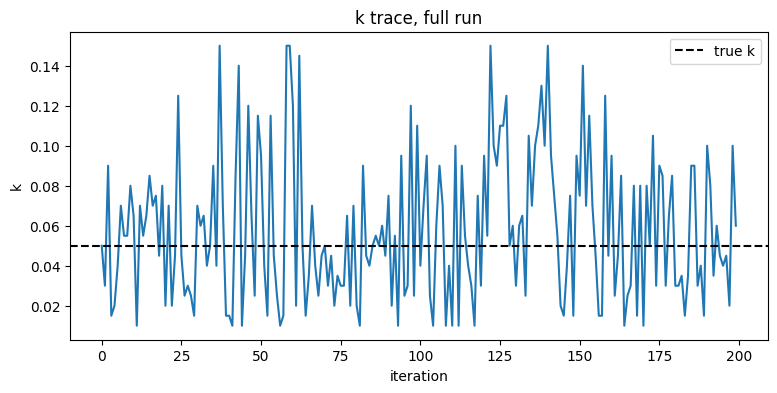

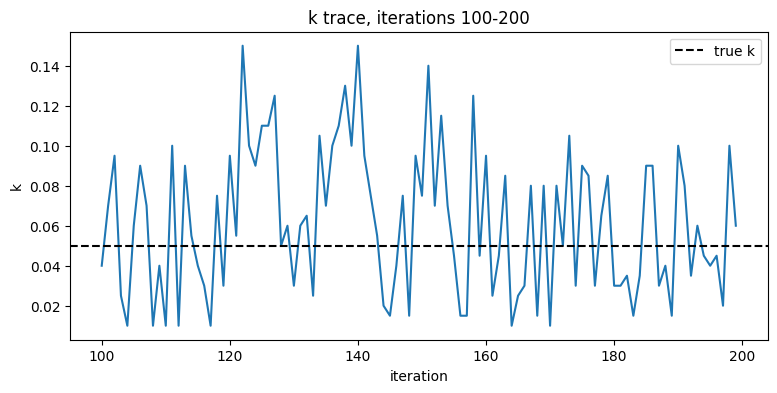

In [84]:
plt.figure(figsize=(9,4))
plt.plot(samples_Lx10['k'])
plt.axhline(k_true, color='k', linestyle='--', label='true k')
plt.xlabel('iteration'); plt.ylabel('k'); plt.legend()
plt.title('k trace, full run')
plt.show()

# second half only, to separate burn-in from settled behavior
burn_in = 100
plt.figure(figsize=(9,4))
plt.plot(range(burn_in, len(samples_Lx10['k'])), samples_Lx10['k'][burn_in:])
plt.axhline(k_true, color='k', linestyle='--', label='true k')
plt.xlabel('iteration'); plt.ylabel('k'); plt.legend()
plt.title(f'k trace, iterations {burn_in}-{len(samples_Lx10["k"])}')
plt.show()

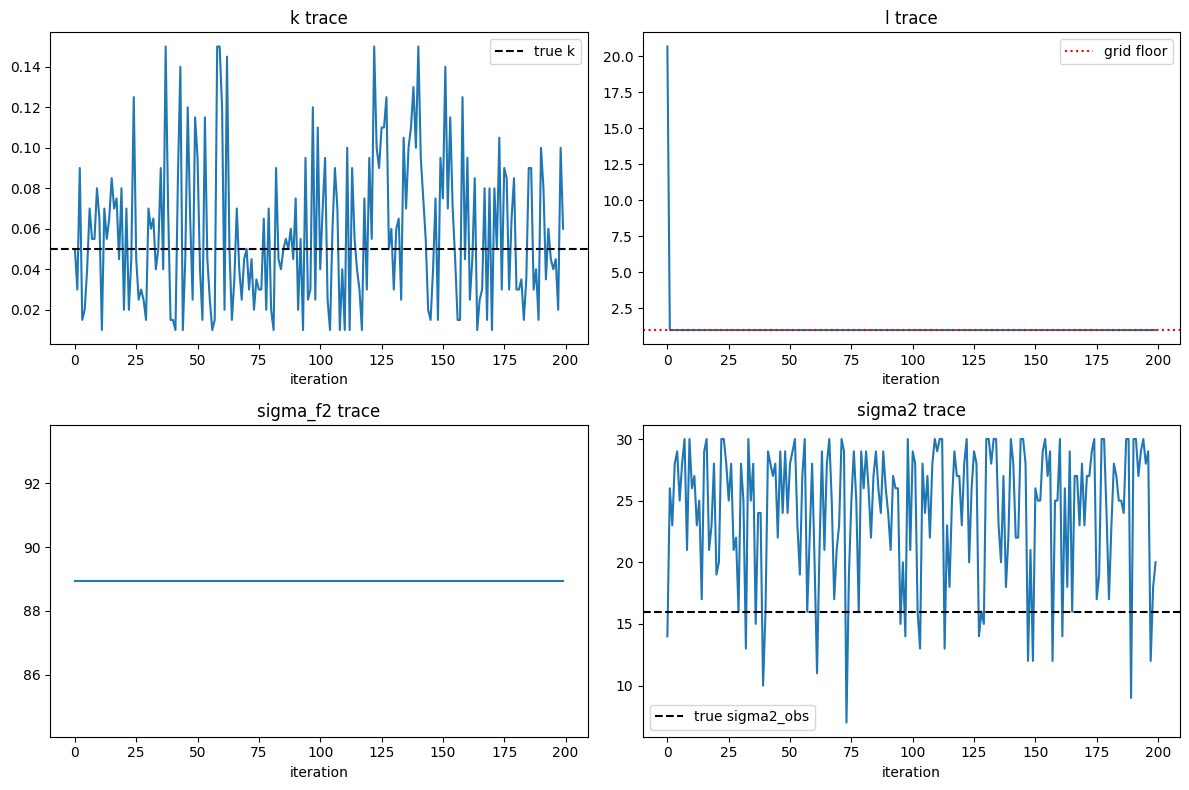

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(samples_Lx10['k'])
axes[0,0].axhline(k_true, color='k', linestyle='--', label='true k')
axes[0,0].set_title('k trace'); axes[0,0].set_xlabel('iteration'); axes[0,0].legend()

axes[0,1].plot(samples_Lx10['l'])
axes[0,1].axhline(l_grid[0].item(), color='r', linestyle=':', label='grid floor')
axes[0,1].set_title('l trace'); axes[0,1].set_xlabel('iteration'); axes[0,1].legend()

axes[1,0].plot(samples_Lx10['sigma_f2'])
axes[1,0].set_title('sigma_f2 trace'); axes[1,0].set_xlabel('iteration')

axes[1,1].plot(samples_Lx10['sigma2'])
axes[1,1].axhline(sigma_obs**2, color='k', linestyle='--', label='true sigma2_obs')
axes[1,1].set_title('sigma2 trace'); axes[1,1].set_xlabel('iteration'); axes[1,1].legend()

plt.tight_layout()
plt.show()

In [86]:
l_arr = np.array(samples_Lx10['l'])
floor = l_grid[0].item()
frac_at_floor = np.mean(np.isclose(l_arr, floor, atol=1e-9))
print(f"l grid floor = {floor}")
print(f"fraction of iterations with l at floor: {frac_at_floor:.1%}")
print(f"l value counts (first 10 unique): {np.unique(l_arr)[:10]}")

l grid floor = 1.0
fraction of iterations with l at floor: 99.5%
l value counts (first 10 unique): [ 1.         20.66666667]


k posterior mean: 0.0616
k posterior std:  0.0360
95% CI (empirical percentile): [0.0100, 0.1352]
true k = 0.05, inside CI: True


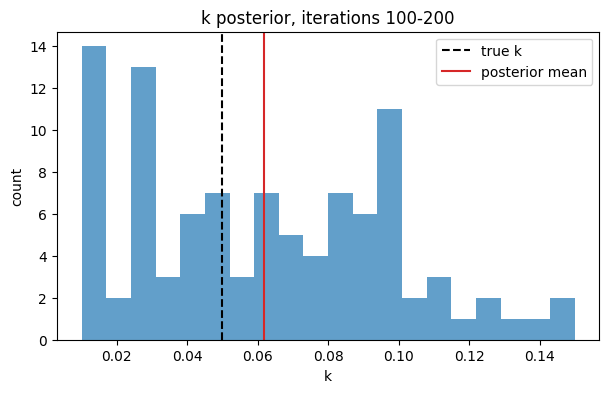

In [87]:
burn_in = 100
k_post = np.array(samples_Lx10['k'][burn_in:])

k_mean = k_post.mean()
k_std = k_post.std()
ci_lo, ci_hi = np.percentile(k_post, [2.5, 97.5])

print(f"k posterior mean: {k_mean:.4f}")
print(f"k posterior std:  {k_std:.4f}")
print(f"95% CI (empirical percentile): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"true k = {k_true}, inside CI: {ci_lo <= k_true <= ci_hi}")

plt.figure(figsize=(7,4))
plt.hist(k_post, bins=20, color='tab:blue', alpha=0.7)
plt.axvline(k_true, color='k', linestyle='--', label='true k')
plt.axvline(k_mean, color='tab:red', linestyle='-', label='posterior mean')
plt.xlabel('k'); plt.ylabel('count')
plt.title(f'k posterior, iterations {burn_in}-{len(samples_Lx10["k"])}')
plt.legend()
plt.show()

In [88]:
# Use a representative state from the run -- e.g. the final x snapshot
x_snap = samples_Lx10['x_snapshot'][-1]
k_snap = samples_Lx10['k'][-1]
sigma2_snap = samples_Lx10['sigma2'][-1]
sigma_f2_snap = samples_Lx10['sigma_f2'][-1]

print("--- l_grid diagnostic (sigma_f2, k, sigma2 held fixed) ---")
for l_val in l_grid:
    ll = log_posterior_k_phi_x(k_snap, x_snap, torch.tensor(sigma_f2_snap), l_val,
                                sigma2_snap, mu_x, y_obs, t_obs).item()
    lp = log_gp_prior_x(x_snap, sigma_f2_snap, l_val.item(), mu_x)
    print(f"l={l_val.item():6.2f}  log_lik={ll:12.2f}  log_prior_x={lp:12.2f}  sum={ll+lp:12.2f}")

print("\n--- sigma_f2_grid diagnostic (l, k, sigma2 held fixed) ---")
for sf_val in sigma_f2_grid:
    ll = log_posterior_k_phi_x(k_snap, x_snap, sf_val, torch.tensor(1.0),
                                sigma2_snap, mu_x, y_obs, t_obs).item()
    lp = log_gp_prior_x(x_snap, sf_val.item(), 1.0, mu_x)
    print(f"sf2={sf_val.item():7.2f}  log_lik={ll:12.2f}  log_prior_x={lp:12.2f}  sum={ll+lp:12.2f}")

--- l_grid diagnostic (sigma_f2, k, sigma2 held fixed) ---
l=  1.00  log_lik=     -105.69  log_prior_x=      -88.13  sum=     -193.82
l=  7.56  log_lik=     -272.31  log_prior_x=  -496171.20  sum=  -496443.52
l= 14.11  log_lik=     -324.31  log_prior_x=  -797564.23  sum=  -797888.55
l= 20.67  log_lik=     -474.70  log_prior_x=  -994337.05  sum=  -994811.75
l= 27.22  log_lik=    -2085.09  log_prior_x= -1421091.87  sum= -1423176.96
l= 33.78  log_lik=     -454.72  log_prior_x= -1582365.06  sum= -1582819.78
l= 40.33  log_lik=      -85.75  log_prior_x= -1654610.79  sum= -1654696.54
l= 46.89  log_lik=     -132.79  log_prior_x= -1691248.54  sum= -1691381.33
l= 53.44  log_lik=     -116.52  log_prior_x= -1722208.75  sum= -1722325.28
l= 60.00  log_lik=     -706.83  log_prior_x= -1747899.83  sum= -1748606.66

--- sigma_f2_grid diagnostic (l, k, sigma2 held fixed) ---
sf2=   0.10  log_lik=     -269.23  log_prior_x=   -22094.91  sum=   -22364.14
sf2=  22.31  log_lik=     -160.18  log_prior_x=     -

In [89]:
# Check the sigma_f2 conditional at several REAL points along the chain,
# using the actual x_current, k, sigma2 that existed at that iteration
check_iters = [0, 1, 2, 5, 20, 100, 199]

for it in check_iters:
    x_it = samples_Lx10['x_snapshot'][it]
    k_it = samples_Lx10['k'][it]
    l_it = samples_Lx10['l'][it]
    sigma2_it = samples_Lx10['sigma2'][it]

    print(f"\n--- iteration {it}  (l={l_it:.2f}, k={k_it:.4f}, sigma2={sigma2_it:.2f}) ---")
    sums = []
    for sf_val in sigma_f2_grid:
        ll = log_posterior_k_phi_x(k_it, x_it, sf_val, torch.tensor(l_it),
                                    sigma2_it, mu_x, y_obs, t_obs).item()
        lp = log_gp_prior_x(x_it, sf_val.item(), l_it, mu_x)
        sums.append(ll + lp)
    sums = np.array(sums)
    probs = np.exp(sums - sums.max())
    probs /= probs.sum()
    for sf_val, s, p in zip(sigma_f2_grid, sums, probs):
        print(f"  sf2={sf_val.item():7.2f}  sum={s:12.2f}  prob={p:.4f}")


--- iteration 0  (l=20.67, k=0.0500, sigma2=14.00) ---
  sf2=   0.10  sum=   -58032.93  prob=0.0000
  sf2=  22.31  sum=    -5009.57  prob=0.0000
  sf2=  44.52  sum=    -4215.51  prob=0.0000
  sf2=  66.73  sum=    -3877.67  prob=0.0000
  sf2=  88.94  sum=    -3678.32  prob=0.0000
  sf2= 111.16  sum=    -3541.85  prob=0.0000
  sf2= 133.37  sum=    -3439.97  prob=0.0000
  sf2= 155.58  sum=    -3359.49  prob=0.0000
  sf2= 177.79  sum=    -3293.32  prob=0.0000
  sf2= 200.00  sum=    -3237.30  prob=1.0000

--- iteration 1  (l=1.00, k=0.0300, sigma2=26.00) ---
  sf2=   0.10  sum=   -24365.98  prob=0.0000
  sf2=  22.31  sum=     -306.41  prob=0.0000
  sf2=  44.52  sum=     -234.13  prob=0.0000
  sf2=  66.73  sum=     -207.81  prob=0.0000
  sf2=  88.94  sum=     -194.58  prob=0.0000
  sf2= 111.16  sum=     -186.93  prob=0.0000
  sf2= 133.37  sum=     -182.14  prob=0.0010
  sf2= 155.58  sum=     -179.02  prob=0.0232
  sf2= 177.79  sum=     -176.92  prob=0.1894
  sf2= 200.00  sum=     -175.50  p

In [90]:
# Recompute the true initial x (same formula run_gibbs uses internally, not stored anywhere)
sf2_0, l0, s2_0 = init_phi_vals
C0 = build_covariance_blocks(t_obs, torch.tensor(sf2_0), torch.tensor(l0))
L0 = torch.linalg.cholesky(C0['xx'] + s2_0*torch.eye(n) + 1e-6*torch.eye(n))
alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
x_init = mu_x + C0['xx'] @ alpha0

def state_before(it):
    if it == 0:
        return x_init, init_k, l0, s2_0
    else:
        return (samples_Lx10['x_snapshot'][it-1], samples_Lx10['k'][it-1],
                samples_Lx10['l'][it-1], samples_Lx10['sigma2'][it-1])

check_iters = [0, 1, 2, 5, 20, 100, 199]

for it in check_iters:
    x_b, k_b, l_b, s2_b = state_before(it)
    print(f"\n--- iteration {it} (state BEFORE this iter's phi/theta update: l={l_b:.2f}, k={k_b:.4f}, sigma2={s2_b:.2f}) ---")
    sums = []
    for sf_val in sigma_f2_grid:
        ll = log_posterior_k_phi_x(k_b, x_b, sf_val, torch.tensor(l_b),
                                    s2_b, mu_x, y_obs, t_obs).item()
        lp = log_gp_prior_x(x_b, sf_val.item(), l_b, mu_x)
        sums.append(ll + lp)
    sums = np.array(sums)
    probs = np.exp(sums - sums.max()); probs /= probs.sum()
    actual = samples_Lx10['sigma_f2'][it]
    for sf_val, s, p in zip(sigma_f2_grid, sums, probs):
        flag = "  <-- actually sampled" if abs(sf_val.item()-actual) < 1e-6 else ""
        print(f"  sf2={sf_val.item():7.2f}  sum={s:12.2f}  prob={p:.4f}{flag}")


--- iteration 0 (state BEFORE this iter's phi/theta update: l=20.67, k=0.0450, sigma2=1.00) ---
  sf2=   0.10  sum=   -29815.18  prob=0.0000
  sf2=  22.31  sum=     -281.77  prob=0.0000
  sf2=  44.52  sum=     -199.16  prob=0.0000
  sf2=  66.73  sum=     -172.17  prob=0.0000
  sf2=  88.94  sum=     -159.02  prob=0.0000  <-- actually sampled
  sf2= 111.16  sum=     -151.36  prob=0.0000
  sf2= 133.37  sum=     -146.40  prob=0.0004
  sf2= 155.58  sum=     -142.96  prob=0.0109
  sf2= 177.79  sum=     -140.47  prob=0.1317
  sf2= 200.00  sum=     -138.60  prob=0.8571

--- iteration 1 (state BEFORE this iter's phi/theta update: l=20.67, k=0.0500, sigma2=14.00) ---
  sf2=   0.10  sum=   -58032.93  prob=0.0000
  sf2=  22.31  sum=    -5009.57  prob=0.0000
  sf2=  44.52  sum=    -4215.51  prob=0.0000
  sf2=  66.73  sum=    -3877.67  prob=0.0000
  sf2=  88.94  sum=    -3678.32  prob=0.0000  <-- actually sampled
  sf2= 111.16  sum=    -3541.85  prob=0.0000
  sf2= 133.37  sum=    -3439.97  prob=0.0

In [91]:
it = 100
x_b, k_b, l_b, s2_b = state_before(it)
print(f"--- iteration {it}, FULL log_posterior_full (all four prior terms included) ---")
for sf_val in sigma_f2_grid:
    full = log_posterior_full(k_b, sf_val.item(), l_b, s2_b, x_b, y_obs, t_obs)
    print(f"  sf2={sf_val.item():7.2f}  log_posterior_full={full}")

--- iteration 100, FULL log_posterior_full (all four prior terms included) ---
  sf2=   0.10  log_posterior_full=-28357.761216540253
  sf2=  22.31  log_posterior_full=-336.7227709253596
  sf2=  44.52  log_posterior_full=-250.2238483093901
  sf2=  66.73  log_posterior_full=-219.09766713114385
  sf2=  88.94  log_posterior_full=-203.54522974395167
  sf2= 111.16  log_posterior_full=-inf
  sf2= 133.37  log_posterior_full=-inf
  sf2= 155.58  log_posterior_full=-inf
  sf2= 177.79  log_posterior_full=-inf
  sf2= 200.00  log_posterior_full=-inf


In [92]:
# Condition number of C_xx across the l_grid, at n=20 -- is it still near-singular?
sf2_fixed = torch.tensor(88.94)
for l_val in l_grid:
    C = build_covariance_blocks(t_obs, sf2_fixed, l_val)
    eigvals = torch.linalg.eigvalsh(C['xx'])
    cond = (eigvals.max() / eigvals.clamp(min=1e-300).min()).item()
    print(f"l={l_val.item():6.2f}  min_eig={eigvals.min().item():.3e}  max_eig={eigvals.max().item():.3e}  cond={cond:.3e}")

l=  1.00  min_eig=8.774e+01  max_eig=9.014e+01  cond=1.027e+00
l=  7.56  min_eig=1.539e-07  max_eig=5.053e+02  cond=3.284e+09
l= 14.11  min_eig=6.241e-15  max_eig=8.539e+02  cond=1.368e+17
l= 20.67  min_eig=-1.366e-14  max_eig=1.109e+03  cond=1.109e+303
l= 27.22  min_eig=-3.500e-14  max_eig=1.287e+03  cond=1.287e+303
l= 33.78  min_eig=-4.597e-14  max_eig=1.411e+03  cond=1.411e+303
l= 40.33  min_eig=-2.981e-14  max_eig=1.497e+03  cond=1.497e+303
l= 46.89  min_eig=-6.453e-14  max_eig=1.557e+03  cond=1.557e+303
l= 53.44  min_eig=-3.307e-14  max_eig=1.601e+03  cond=1.601e+303
l= 60.00  min_eig=-5.589e-14  max_eig=1.634e+03  cond=1.634e+303


In [93]:
rel_jitter = 1e-6
sf2_fixed = torch.tensor(88.94)
for l_val in l_grid:
    C = build_covariance_blocks(t_obs, sf2_fixed, l_val)
    jitter = rel_jitter * sf2_fixed.item()
    eigvals = torch.linalg.eigvalsh(C['xx'] + jitter*torch.eye(n))
    print(f"l={l_val.item():6.2f}  jitter={jitter:.2e}  min_eig={eigvals.min().item():.3e}  max_eig={eigvals.max().item():.3e}  cond={(eigvals.max()/eigvals.min()).item():.3e}")

l=  1.00  jitter=8.89e-05  min_eig=8.774e+01  max_eig=9.014e+01  cond=1.027e+00
l=  7.56  jitter=8.89e-05  min_eig=8.909e-05  max_eig=5.053e+02  cond=5.672e+06
l= 14.11  jitter=8.89e-05  min_eig=8.894e-05  max_eig=8.539e+02  cond=9.601e+06
l= 20.67  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.109e+03  cond=1.247e+07
l= 27.22  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.287e+03  cond=1.447e+07
l= 33.78  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.411e+03  cond=1.586e+07
l= 40.33  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.497e+03  cond=1.683e+07
l= 46.89  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.557e+03  cond=1.751e+07
l= 53.44  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.601e+03  cond=1.800e+07
l= 60.00  jitter=8.89e-05  min_eig=8.894e-05  max_eig=1.634e+03  cond=1.837e+07


In [97]:
sf2_fixed = 88.94
for l_val in l_grid:
    lp = log_gp_prior_x(x_smoothed, sf2_fixed, l_val.item(), mu_x, rel_jitter=1e-6)
    print(f"l={l_val.item():6.2f}  log_gp_prior_x={lp:.2f}")

l=  1.00  log_gp_prior_x=-65.72
l=  7.56  log_gp_prior_x=-12.67
l= 14.11  log_gp_prior_x=17.91
l= 20.67  log_gp_prior_x=24.11
l= 27.22  log_gp_prior_x=-55.73
l= 33.78  log_gp_prior_x=-325.63
l= 40.33  log_gp_prior_x=-845.36
l= 46.89  log_gp_prior_x=-2127.16
l= 53.44  log_gp_prior_x=-4195.58
l= 60.00  log_gp_prior_x=-6110.29


In [99]:
# sanity check: does jitter matter at all once sigma2 is added?
for l_val in l_grid:
    C0 = build_covariance_blocks(t_obs, torch.tensor(88.94), l_val)
    for s2 in [sigma2_grid[0].item(), sigma2_grid[-1].item()]:  # worst case: smallest sigma2
        eigvals = torch.linalg.eigvalsh(C0['xx'] + s2*torch.eye(n))
        print(f"l={l_val.item():6.2f}  sigma2={s2:5.1f}  min_eig={eigvals.min().item():.3e}")

l=  1.00  sigma2=  1.0  min_eig=8.874e+01
l=  1.00  sigma2= 30.0  min_eig=1.177e+02
l=  7.56  sigma2=  1.0  min_eig=1.000e+00
l=  7.56  sigma2= 30.0  min_eig=3.000e+01
l= 14.11  sigma2=  1.0  min_eig=1.000e+00
l= 14.11  sigma2= 30.0  min_eig=3.000e+01
l= 20.67  sigma2=  1.0  min_eig=1.000e+00
l= 20.67  sigma2= 30.0  min_eig=3.000e+01
l= 27.22  sigma2=  1.0  min_eig=1.000e+00
l= 27.22  sigma2= 30.0  min_eig=3.000e+01
l= 33.78  sigma2=  1.0  min_eig=1.000e+00
l= 33.78  sigma2= 30.0  min_eig=3.000e+01
l= 40.33  sigma2=  1.0  min_eig=1.000e+00
l= 40.33  sigma2= 30.0  min_eig=3.000e+01
l= 46.89  sigma2=  1.0  min_eig=1.000e+00
l= 46.89  sigma2= 30.0  min_eig=3.000e+01
l= 53.44  sigma2=  1.0  min_eig=1.000e+00
l= 53.44  sigma2= 30.0  min_eig=3.000e+01
l= 60.00  sigma2=  1.0  min_eig=1.000e+00
l= 60.00  sigma2= 30.0  min_eig=3.000e+01
